In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime, timedelta
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import tensorflow as tf
import warnings
import os
warnings.filterwarnings('ignore')

Sequential        = tf.keras.models.Sequential
LSTM              = tf.keras.layers.LSTM
Dense             = tf.keras.layers.Dense
Dropout           = tf.keras.layers.Dropout
EarlyStopping     = tf.keras.callbacks.EarlyStopping
ReduceLROnPlateau = tf.keras.callbacks.ReduceLROnPlateau

# Timestamp satu kali per run — dipakai semua file output
RUN_TS = datetime.now().strftime('%Y%m%d_%H%M%S')
RESULT_DIR = os.path.join(os.path.dirname(os.path.abspath('kurs_rupiah.ipynb')), 'Result', RUN_TS)
os.makedirs(RESULT_DIR, exist_ok=True)
print(f"Output folder: {RESULT_DIR}")

START = '2001-06-28'
END   = (datetime.today() + timedelta(days=1)).strftime('%Y-%m-%d')

df = yf.download('USDIDR=X', start=START, end=END)
df.columns = df.columns.droplevel(1)
df['Close'] = df['Close'].ffill()

print(f"Rentang       : {df.index[0].date()} s.d. {df.index[-1].date()}")
print(f"Total rows    : {len(df)}")
print(f"Close terakhir: {df['Close'].iloc[-1]:,.2f} IDR  ({df.index[-1].date()})")

Output folder: d:\sentiment-analysis-lstm\Result\20260522_163403


[*********************100%***********************]  1 of 1 completed

Rentang       : 2001-06-28 s.d. 2026-05-22
Total rows    : 6285
Close terakhir: 17,700.00 IDR  (2026-05-22)


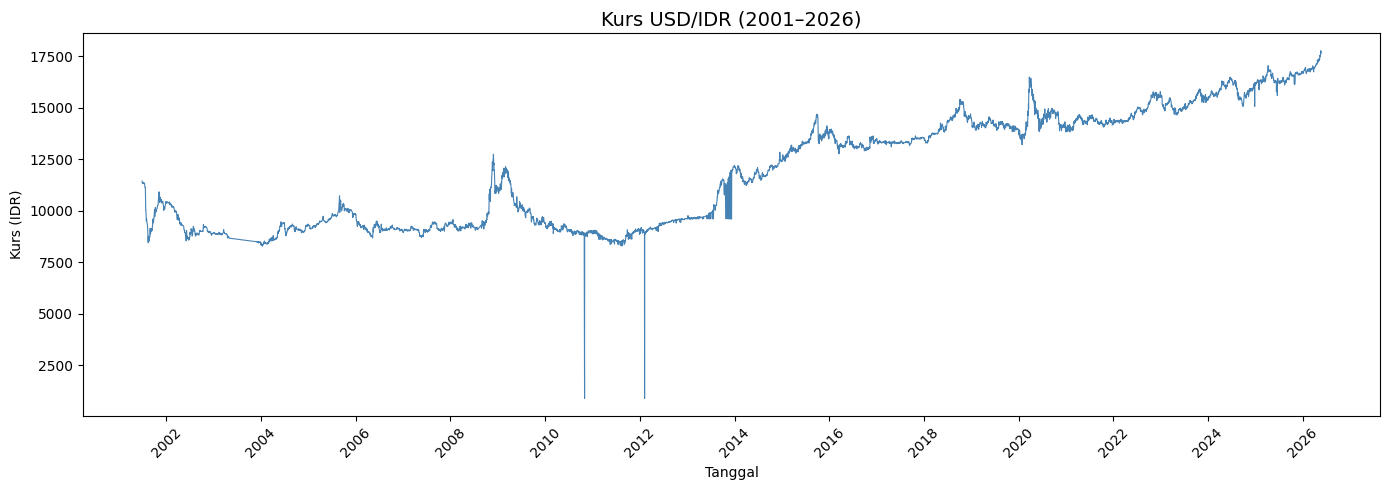

In [2]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df.index, df['Close'], linewidth=0.8, color='steelblue')
ax.set_title('Kurs USD/IDR (2001–2026)', fontsize=14)
ax.set_xlabel('Tanggal')
ax.set_ylabel('Kurs (IDR)')
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(os.path.join(RESULT_DIR, f'{RUN_TS}_historis_kurs_usdidr.png'), dpi=150)
plt.show()

In [3]:
data_raw = df['Close'].values.astype(float)
data_diff = np.diff(data_raw)

scaler = MinMaxScaler(feature_range=(-1, 1))
data_scaled = scaler.fit_transform(data_diff.reshape(-1, 1))

print(f"Range perubahan harian: {data_diff.min():+.1f} s.d. {data_diff.max():+.1f} IDR")

Range perubahan harian: -8036.1 s.d. +8038.0 IDR


In [4]:
WINDOW = 60

def create_sequences(data, window):
    X, y = [], []
    for i in range(window, len(data)):
        X.append(data[i - window:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

X, y = create_sequences(data_scaled, WINDOW)
print(f"X: {X.shape}  y: {y.shape}")

X: (6224, 60)  y: (6224,)


In [5]:
split = int(len(X) * 0.8)

X_train = X[:split].reshape(-1, WINDOW, 1)
X_test  = X[split:].reshape(-1, WINDOW, 1)
y_train = y[:split]
y_test  = y[split:]

print(f"Train: {X_train.shape}  Test: {X_test.shape}")

Train: (4979, 60, 1)  Test: (1245, 60, 1)


In [6]:
tf.random.set_seed(42)

model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(WINDOW, 1)),
    Dropout(0.2),
    LSTM(32, return_sequences=False),
    Dropout(0.2),
    Dense(1)
])

model.compile(optimizer='adam', loss='mean_squared_error')
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,345 (114.63 KB)

 Trainable params: 29,345 (114.63 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.0012 - val_loss: 3.1672e-04 - learning_rate: 0.0010
Epoch 2/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 0.0011 - val_loss: 3.1666e-04 - learning_rate: 0.0010
Epoch 3/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 0.0011 - val_loss: 3.0977e-04 - learning_rate: 0.0010
Epoch 4/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 0.0011 - val_loss: 3.0254e-04 - learning_rate: 0.0010
Epoch 5/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 0.0010 - val_loss: 2.9429e-04 - learning_rate: 0.0010
Epoch 6/100
137/141 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 9.2308e-04
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
141/141 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 9.2437e-04 - val_loss: 2.8615e-04 - learning_rate: 0.0010
Epoch 7/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 8.1353e-04 - val_loss: 2.8940e-04 - learning_rate: 5.0000e-04
Epoch 8/100
141/141 ━━━━━━━━━━━━━━━━━━━

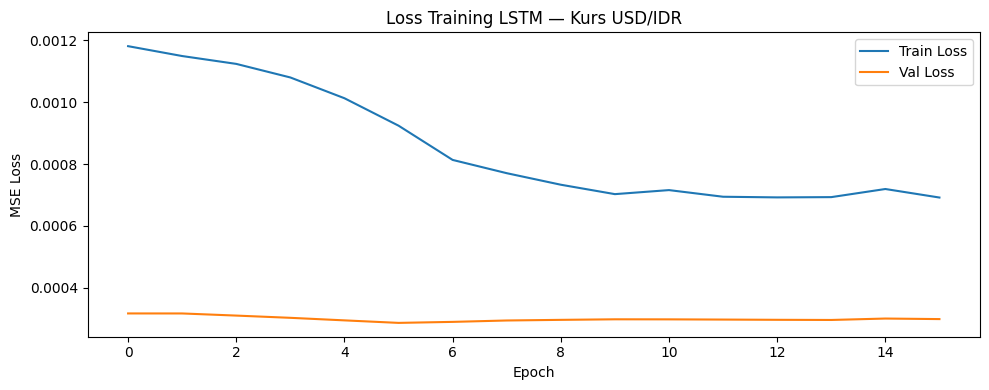

In [7]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, verbose=1)
]

history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.1,
    callbacks=callbacks,
    verbose=1
)

plt.figure(figsize=(10, 4))
plt.plot(history.history['loss'],     label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss Training LSTM — Kurs USD/IDR')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(RESULT_DIR, f'{RUN_TS}_loss_training.png'), dpi=150)
plt.show()

In [8]:
y_pred_scaled = model.predict(X_test)
y_pred_diff   = scaler.inverse_transform(y_pred_scaled).flatten()

prev_prices  = data_raw[WINDOW + split : WINDOW + split + len(y_test)]
y_pred_price = prev_prices + y_pred_diff
y_true_price = data_raw[WINDOW + split + 1 : WINDOW + split + 1 + len(y_test)]

mae  = mean_absolute_error(y_true_price, y_pred_price)
rmse = np.sqrt(mean_squared_error(y_true_price, y_pred_price))
print(f"MAE : {mae:,.2f} IDR")
print(f"RMSE: {rmse:,.2f} IDR")

39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
MAE : 55.56 IDR
RMSE: 86.72 IDR


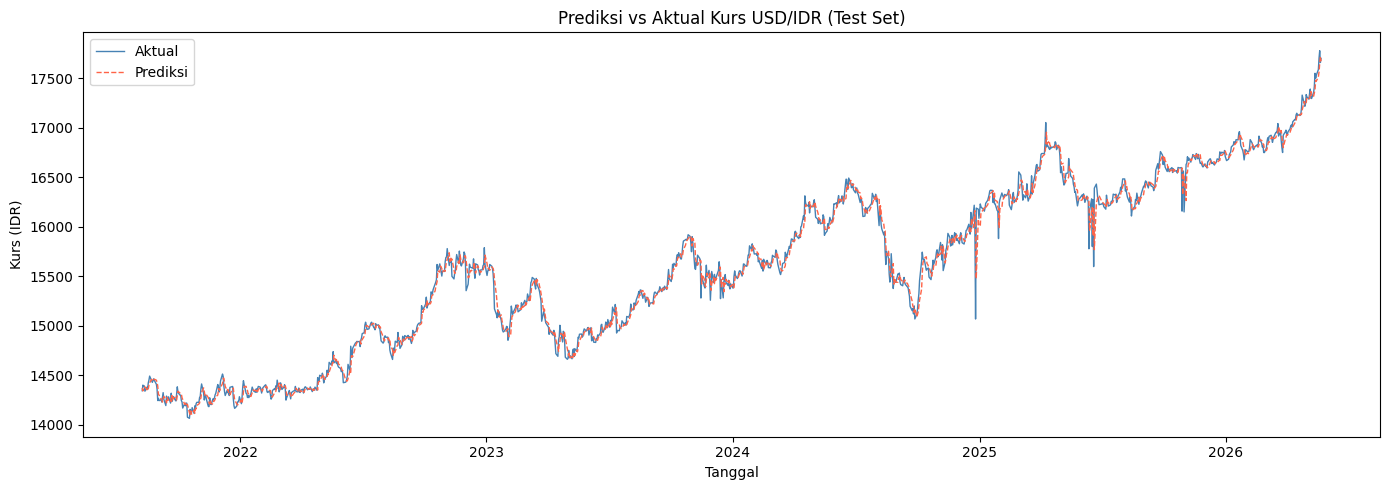

In [9]:
test_dates = df.index[WINDOW + split + 1 : WINDOW + split + 1 + len(y_test)]

plt.figure(figsize=(14, 5))
plt.plot(test_dates, y_true_price, label='Aktual',   linewidth=1.0, color='steelblue')
plt.plot(test_dates, y_pred_price, label='Prediksi', linewidth=1.0, color='tomato', linestyle='--')
plt.title('Prediksi vs Aktual Kurs USD/IDR (Test Set)')
plt.xlabel('Tanggal')
plt.ylabel('Kurs (IDR)')
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(RESULT_DIR, f'{RUN_TS}_prediksi_vs_aktual_testset.png'), dpi=150)
plt.show()

=== Backtest 7 Hari ===
  MAE      : 161.65 IDR
  RMSE     : 183.86 IDR
  MAPE     : 0.91%
  Akurasi  : 99.09%


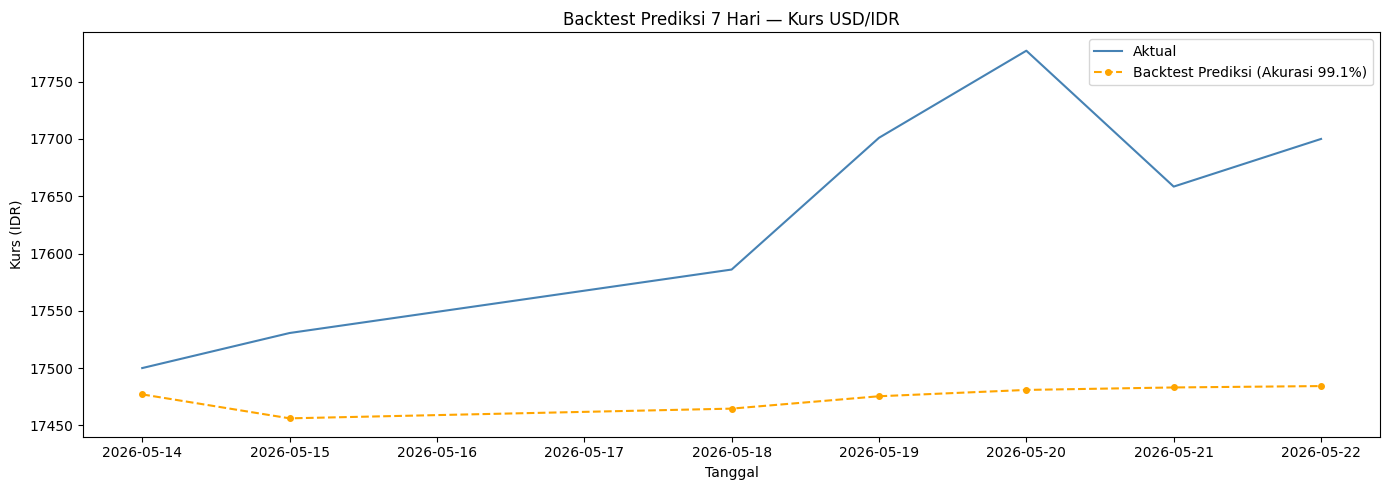

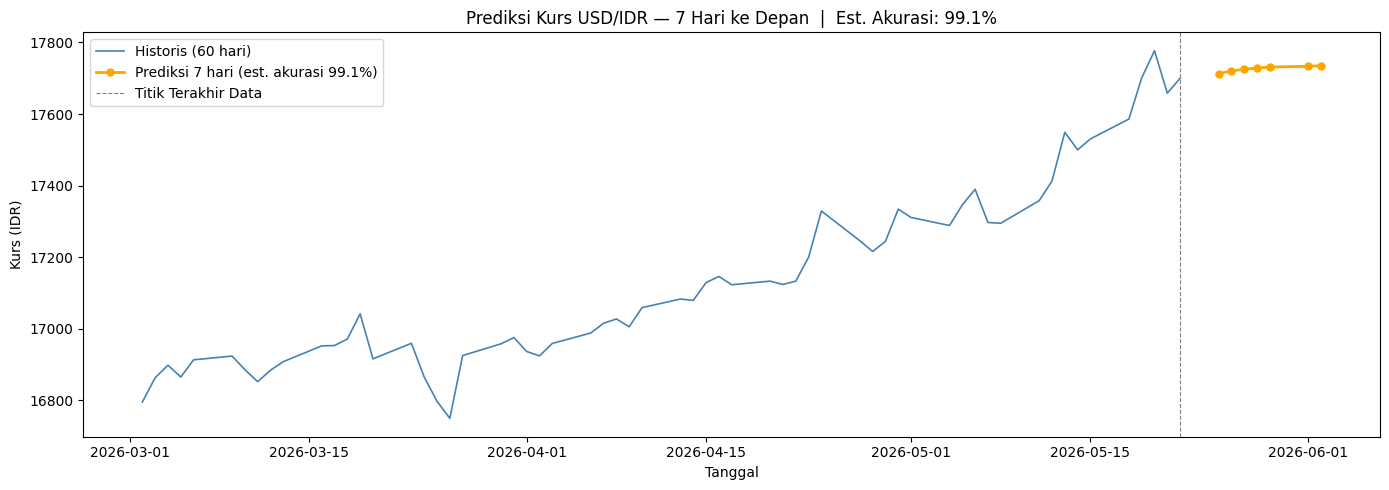


Est. Akurasi Forecast 7 Hari: 99.09%

   Tanggal  Prediksi Kurs (IDR)
2026-05-25                17712
2026-05-26                17720
2026-05-27                17725
2026-05-28                17728
2026-05-29                17731
2026-06-01                17733
2026-06-02                17735


In [10]:
FORECAST_DAYS = 7

# --- Backtest: simulasi forecast 7 hari pada data yang sudah diketahui ---
bt_start_idx  = len(data_scaled) - FORECAST_DAYS
bt_seq        = data_scaled[bt_start_idx - WINDOW : bt_start_idx].reshape(1, WINDOW, 1)
bt_last_price = data_raw[bt_start_idx]

bt_changes_scaled = []
for _ in range(FORECAST_DAYS):
    p = model.predict(bt_seq, verbose=0)[0, 0]
    bt_changes_scaled.append(p)
    bt_seq = np.append(bt_seq[:, 1:, :], [[[p]]], axis=1)

bt_changes = scaler.inverse_transform(
    np.array(bt_changes_scaled).reshape(-1, 1)
).flatten()
bt_changes = np.clip(bt_changes, -500, 500)

bt_prices = [bt_last_price]
for c in bt_changes:
    bt_prices.append(bt_prices[-1] + c)
bt_prices = np.array(bt_prices[1:])

bt_actual   = data_raw[bt_start_idx + 1 : bt_start_idx + 1 + FORECAST_DAYS]
bt_dates    = df.index[bt_start_idx + 1 : bt_start_idx + 1 + FORECAST_DAYS]
bt_mape     = np.mean(np.abs((bt_actual - bt_prices) / bt_actual)) * 100
bt_accuracy = 100 - bt_mape
bt_mae      = np.mean(np.abs(bt_actual - bt_prices))
bt_rmse     = np.sqrt(np.mean((bt_actual - bt_prices) ** 2))

print(f"=== Backtest {FORECAST_DAYS} Hari ===")
print(f"  MAE      : {bt_mae:,.2f} IDR")
print(f"  RMSE     : {bt_rmse:,.2f} IDR")
print(f"  MAPE     : {bt_mape:.2f}%")
print(f"  Akurasi  : {bt_accuracy:.2f}%")

plt.figure(figsize=(14, 5))
plt.plot(bt_dates, bt_actual, label='Aktual', color='steelblue', linewidth=1.5)
plt.plot(bt_dates, bt_prices,
         label=f'Backtest Prediksi (Akurasi {bt_accuracy:.1f}%)',
         color='orange', linewidth=1.5, linestyle='--', marker='o', markersize=4)
plt.title(f'Backtest Prediksi {FORECAST_DAYS} Hari — Kurs USD/IDR')
plt.xlabel('Tanggal')
plt.ylabel('Kurs (IDR)')
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(RESULT_DIR, f'{RUN_TS}_backtest_{FORECAST_DAYS}hari.png'), dpi=150)
plt.show()

# --- Forecast 7 hari ke depan ---
last_seq   = data_scaled[-WINDOW:].reshape(1, WINDOW, 1)
last_price = data_raw[-1]

future_changes_scaled = []
for _ in range(FORECAST_DAYS):
    pred = model.predict(last_seq, verbose=0)[0, 0]
    future_changes_scaled.append(pred)
    last_seq = np.append(last_seq[:, 1:, :], [[[pred]]], axis=1)

future_changes = scaler.inverse_transform(
    np.array(future_changes_scaled).reshape(-1, 1)
).flatten()
future_changes = np.clip(future_changes, -500, 500)

future_prices = [last_price]
for c in future_changes:
    future_prices.append(future_prices[-1] + c)
future_prices = np.array(future_prices[1:]).reshape(-1, 1)

last_date    = df.index[-1]
future_dates = pd.bdate_range(start=last_date + pd.Timedelta(days=1), periods=FORECAST_DAYS)

plt.figure(figsize=(14, 5))
plt.plot(df.index[-60:], data_raw[-60:], label='Historis (60 hari)', color='steelblue', linewidth=1.2)
plt.plot(future_dates, future_prices,
         label=f'Prediksi {FORECAST_DAYS} hari (est. akurasi {bt_accuracy:.1f}%)',
         color='orange', linewidth=2, marker='o', markersize=5)
plt.axvline(x=last_date, color='gray', linestyle='--', linewidth=0.8, label='Titik Terakhir Data')
plt.title(f'Prediksi Kurs USD/IDR — {FORECAST_DAYS} Hari ke Depan  |  Est. Akurasi: {bt_accuracy:.1f}%')
plt.xlabel('Tanggal')
plt.ylabel('Kurs (IDR)')
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(RESULT_DIR, f'{RUN_TS}_prediksi_{FORECAST_DAYS}hari_ke_depan.png'), dpi=150)
plt.show()

pred_df = pd.DataFrame({
    'Tanggal'            : future_dates.strftime('%Y-%m-%d'),
    'Prediksi Kurs (IDR)': future_prices.flatten().astype(int)
})
print(f"\nEst. Akurasi Forecast {FORECAST_DAYS} Hari: {bt_accuracy:.2f}%\n")
print(pred_df.to_string(index=False))

In [11]:
csv_path = os.path.join(RESULT_DIR, f'{RUN_TS}_tabel_prediksi_{FORECAST_DAYS}hari.csv')
pred_df.to_csv(csv_path, index=False)

summary_lines = [
    f"============================",
    f"  HASIL RUN: {RUN_TS}",
    f"============================",
    f"",
    f"[Data]",
    f"  Sumber         : Yahoo Finance (USDIDR=X)",
    f"  Rentang        : {df.index[0].date()} s.d. {df.index[-1].date()}",
    f"  Total baris    : {len(df)}",
    f"  Close terakhir : {df['Close'].iloc[-1]:,.2f} IDR  ({df.index[-1].date()})",
    f"",
    f"[Model]",
    f"  Arsitektur     : LSTM(64) → Dropout(0.2) → LSTM(32) → Dropout(0.2) → Dense(1)",
    f"  Window         : {WINDOW} hari",
    f"  Split          : 80% train / 20% test",
    f"  Epochs run     : {len(history.history['loss'])}",
    f"  Train Loss     : {history.history['loss'][-1]:.6f}",
    f"  Val Loss       : {history.history['val_loss'][-1]:.6f}",
    f"",
    f"[Evaluasi Test Set (single-step)]",
    f"  MAE            : {mae:,.2f} IDR",
    f"  RMSE           : {rmse:,.2f} IDR",
    f"",
    f"[Backtest {FORECAST_DAYS} Hari (multi-step kumulatif)]",
    f"  MAE            : {bt_mae:,.2f} IDR",
    f"  RMSE           : {bt_rmse:,.2f} IDR",
    f"  MAPE           : {bt_mape:.2f}%",
    f"  Akurasi        : {bt_accuracy:.2f}%",
    f"",
    f"[Prediksi {FORECAST_DAYS} Hari ke Depan]",
    f"  Est. Akurasi   : {bt_accuracy:.2f}%",
    pred_df.to_string(index=False),
    f"",
    f"[File Output]",
    f"  {RUN_TS}_historis_kurs_usdidr.png",
    f"  {RUN_TS}_loss_training.png",
    f"  {RUN_TS}_prediksi_vs_aktual_testset.png",
    f"  {RUN_TS}_backtest_{FORECAST_DAYS}hari.png",
    f"  {RUN_TS}_prediksi_{FORECAST_DAYS}hari_ke_depan.png",
    f"  {RUN_TS}_tabel_prediksi_{FORECAST_DAYS}hari.csv",
    f"  {RUN_TS}_summary.txt",
]

txt_path = os.path.join(RESULT_DIR, f'{RUN_TS}_summary.txt')
with open(txt_path, 'w', encoding='utf-8') as f:
    f.write('\n'.join(summary_lines))

print('\n'.join(summary_lines))
print(f"\nSemua output tersimpan di:\n  {RESULT_DIR}")

  HASIL RUN: 20260522_163403

[Data]
  Sumber         : Yahoo Finance (USDIDR=X)
  Rentang        : 2001-06-28 s.d. 2026-05-22
  Total baris    : 6285
  Close terakhir : 17,700.00 IDR  (2026-05-22)

[Model]
  Arsitektur     : LSTM(64) → Dropout(0.2) → LSTM(32) → Dropout(0.2) → Dense(1)
  Window         : 60 hari
  Split          : 80% train / 20% test
  Epochs run     : 16
  Train Loss     : 0.000692
  Val Loss       : 0.000298

[Evaluasi Test Set (single-step)]
  MAE            : 55.56 IDR
  RMSE           : 86.72 IDR

[Backtest 7 Hari (multi-step kumulatif)]
  MAE            : 161.65 IDR
  RMSE           : 183.86 IDR
  MAPE           : 0.91%
  Akurasi        : 99.09%

[Prediksi 7 Hari ke Depan]
  Est. Akurasi   : 99.09%
   Tanggal  Prediksi Kurs (IDR)
2026-05-25                17712
2026-05-26                17720
2026-05-27                17725
2026-05-28                17728
2026-05-29                17731
2026-06-01                17733
2026-06-02                17735

[File Outpu